# 04 — Part 2: Traffic Correlation Analysis

Core question: **does a customer's mix of top- vs bottom-funnel campaigns leave a
detectable fingerprint in how traffic arrives at their website?**

We use `campaigns_labeled.csv` (from Part 1) + `traffic.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

raw = pd.read_csv("campaigns_unlabeled.csv")        # monthly campaign rows (for spend)
labels = pd.read_csv("campaigns_labeled.csv")        # campaign_id -> funnel_level
traffic = pd.read_csv("traffic.csv")                 # customer x month traffic

print("campaign monthly rows:", raw.shape)
print("labels:", labels.shape)
print("traffic:", traffic.shape)


campaign monthly rows: (4546, 20)
labels: (637, 9)
traffic: (1440, 13)


## 1. Join and prepare

Each campaign monthly row has `spend_usd`. We attach the funnel label, then
aggregate to **customer x month**.


In [2]:
# attach funnel label to every monthly campaign row
camp_monthly = raw.merge(labels[["campaign_id", "funnel_level"]], on="campaign_id", how="left")
print("rows missing a label:", camp_monthly.funnel_level.isna().sum())

# spend per customer x month x funnel level
funnel_spend = (camp_monthly
                .groupby(["customer_id", "month", "funnel_level"])
                .spend_usd.sum()
                .unstack(fill_value=0.0)
                .reset_index())
funnel_spend.columns.name = None
if "bottom" not in funnel_spend: funnel_spend["bottom"] = 0.0
if "top" not in funnel_spend: funnel_spend["top"] = 0.0
funnel_spend["total_spend"] = funnel_spend.top + funnel_spend.bottom
funnel_spend.head()


rows missing a label: 0


,customer_id,month,bottom,top,total_spend
0,CUST-0001,1,0.00,3760.57,3760.57
1,CUST-0001,2,1364.04,1546.99,2911.03
2,CUST-0001,3,9936.64,1656.17,11592.81
3,CUST-0001,4,7041.18,3689.25,10730.43
4,CUST-0001,5,7038.27,4309.62,11347.89


### Choosing the funnel-mix metric

Candidates:
- **raw bottom-funnel spend** — not comparable across customers; a big spender dominates.
- **share of spend on bottom-funnel** — normalises out customer size, captures *strategy*. ✅
- **number / share of campaigns** — ignores budget; a \$10/day campaign counts the same as a \$5000/day one.

We use **`bottom_spend_share = bottom_spend / total_spend`** — it is in [0, 1],
0 = pure top-funnel month, 1 = pure bottom-funnel month, and it reflects where the
customer actually puts money.


In [3]:
funnel_spend["bottom_spend_share"] = (
    funnel_spend.bottom / funnel_spend.total_spend.replace(0, np.nan)
)
# also a campaign-count version, for comparison
camp_count = (camp_monthly
              .groupby(["customer_id", "month", "funnel_level"])
              .campaign_id.nunique()
              .unstack(fill_value=0)
              .reset_index())
camp_count.columns.name = None
for c in ("top", "bottom"):
    if c not in camp_count: camp_count[c] = 0
camp_count["bottom_campaign_share"] = (
    camp_count.bottom / (camp_count.top + camp_count.bottom).replace(0, np.nan)
)

funnel_mix = funnel_spend.merge(
    camp_count[["customer_id", "month", "bottom_campaign_share"]],
    on=["customer_id", "month"], how="left",
)
print(funnel_mix.bottom_spend_share.describe())


count    1384.000000
mean        0.423125
std         0.366910
min         0.000000
25%         0.075232
50%         0.338907
75%         0.750810
max         1.000000
Name: bottom_spend_share, dtype: float64


### Months with no active campaigns

`traffic.csv` has a row for every customer x month. Some customer-months have
**no campaigns at all** -> no funnel mix can be computed.

Decision: **drop no-campaign months from the correlation analysis.** Reasoning —
funnel mix is undefined there, and imputing 0 or 0.5 would invent a strategy that
did not exist. We report how many rows this removes so the reader sees the coverage.


In [4]:
df = traffic.merge(funnel_mix, on=["customer_id", "month"], how="left")
n_total = len(df)
n_no_campaign = df.bottom_spend_share.isna().sum()
print(f"total customer-months:        {n_total}")
print(f"no-campaign (dropped):        {n_no_campaign}  ({n_no_campaign/n_total:.1%})")

df = df.dropna(subset=["bottom_spend_share"]).reset_index(drop=True)
print(f"analysis rows:                {len(df)}")


total customer-months:        1440
no-campaign (dropped):        56  (3.9%)
analysis rows:                1384


## 2. Build traffic features

Convert raw session counts into **shares** of total sessions, so customers of
different sizes are comparable.


In [5]:
src_cols = ["branded_search_sessions", "nonbranded_search_sessions", "direct_sessions",
            "social_sessions", "email_sessions", "referral_sessions"]
for c in src_cols:
    df[c.replace("_sessions", "_share")] = df[c] / df.total_sessions

share_cols = [c.replace("_sessions", "_share") for c in src_cols]
quality_cols = ["new_visitor_rate", "bounce_rate", "pages_per_session", "onsite_conversion_rate"]
df[share_cols + quality_cols].describe().round(3)


,branded_search_share,nonbranded_search_share,direct_share,social_share,email_share,referral_share,new_visitor_rate,bounce_rate,pages_per_session,onsite_conversion_rate
count,1384.000,1384.000,1384.000,1384.000,1384.000,1384.000,1384.000,1384.000,1384.000,1384.000
mean,0.288,0.245,0.180,0.125,0.058,0.103,0.746,0.573,3.185,0.024
std,0.061,0.075,0.072,0.064,0.032,0.017,0.098,0.091,0.580,0.011
min,0.061,0.063,0.040,0.020,0.006,0.098,0.482,0.319,1.800,0.001
25%,0.252,0.191,0.121,0.076,0.033,0.100,0.671,0.507,2.730,0.015
50%,0.295,0.245,0.170,0.117,0.052,0.100,0.754,0.585,3.150,0.023
75%,0.328,0.293,0.231,0.166,0.077,0.100,0.827,0.645,3.590,0.033
max,0.453,0.570,0.433,0.340,0.172,0.280,0.930,0.805,4.890,0.051


## 3. Correlate funnel mix with traffic source composition

Hypothesis: more **bottom-funnel** spend -> more **branded search** & **direct**
(warm audiences who already know the brand); more **top-funnel** spend -> more
**social** & **non-branded search** (cold reach).


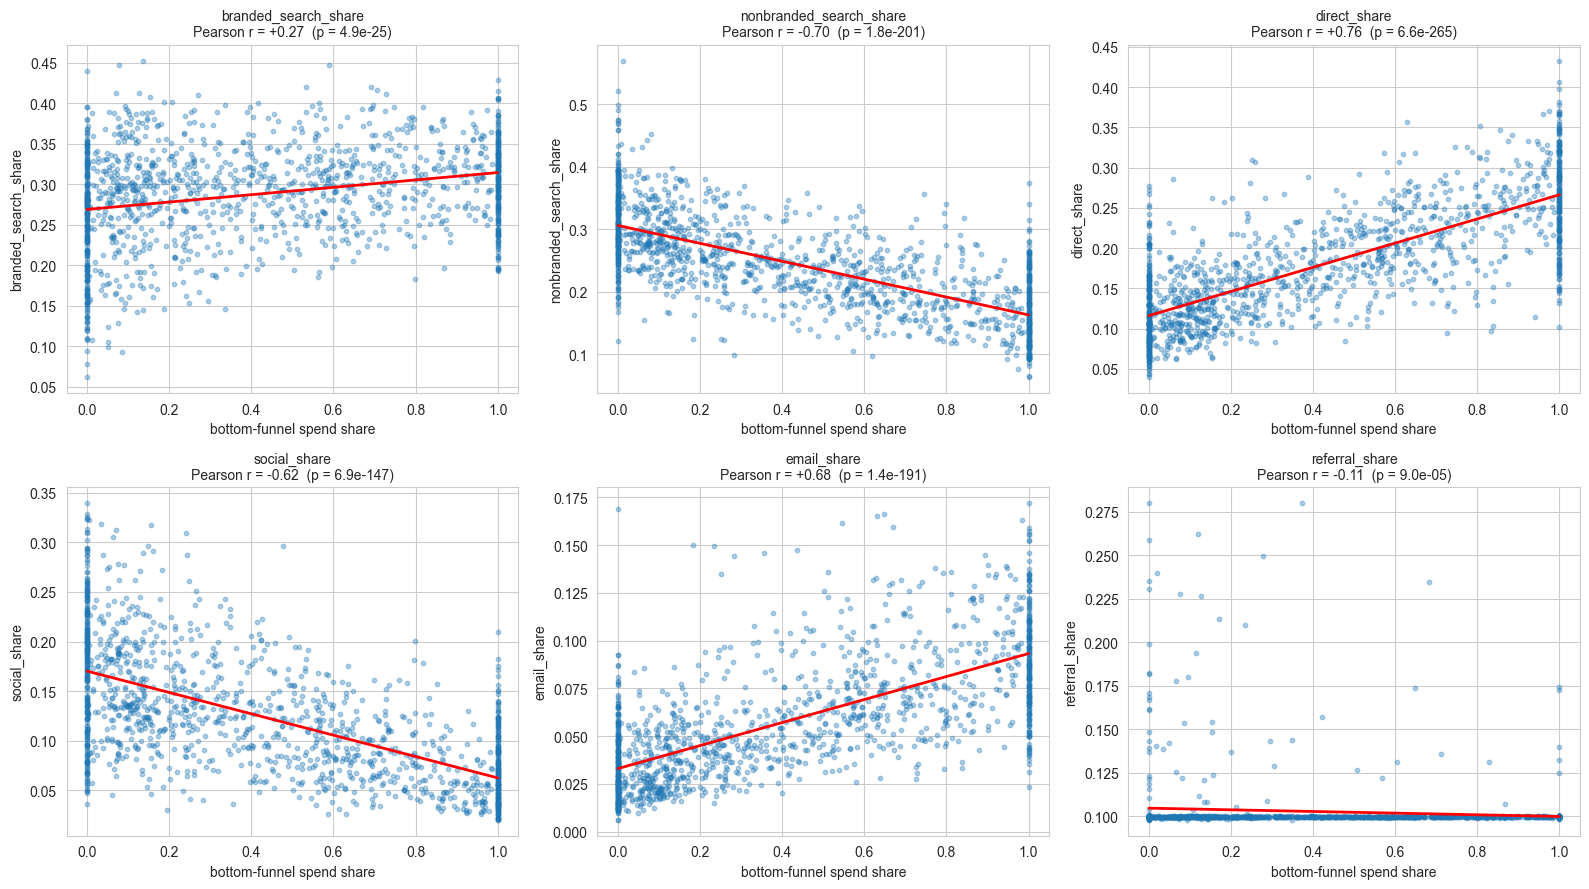

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, share_cols):
    ax.scatter(df.bottom_spend_share, df[col], s=10, alpha=0.35)
    r, p = stats.pearsonr(df.bottom_spend_share, df[col])
    # regression line
    b, a = np.polyfit(df.bottom_spend_share, df[col], 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(xs, a + b * xs, color="red", lw=2)
    ax.set_xlabel("bottom-funnel spend share")
    ax.set_ylabel(col)
    ax.set_title(f"{col}\nPearson r = {r:+.2f}  (p = {p:.1e})", fontsize=10)
plt.tight_layout(); plt.show()


## 4. Correlate funnel mix with traffic quality

Hypothesis: more **top-funnel** -> more first-time visitors, higher bounce, fewer
pages/session, lower on-site conversion (cold traffic). More **bottom-funnel** ->
the opposite (warm, intent-rich traffic).


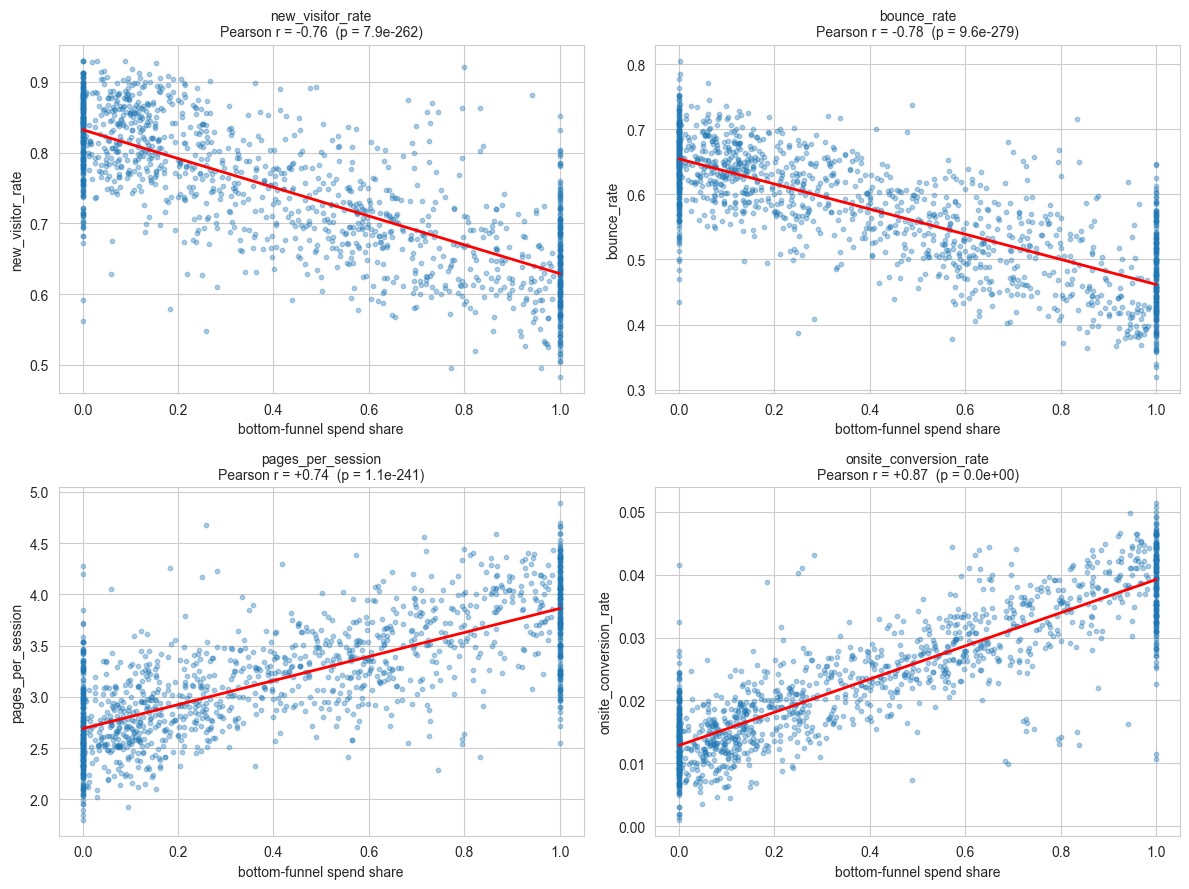

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, quality_cols):
    ax.scatter(df.bottom_spend_share, df[col], s=10, alpha=0.35)
    r, p = stats.pearsonr(df.bottom_spend_share, df[col])
    b, a = np.polyfit(df.bottom_spend_share, df[col], 1)
    xs = np.linspace(0, 1, 50)
    ax.plot(xs, a + b * xs, color="red", lw=2)
    ax.set_xlabel("bottom-funnel spend share")
    ax.set_ylabel(col)
    ax.set_title(f"{col}\nPearson r = {r:+.2f}  (p = {p:.1e})", fontsize=10)
plt.tight_layout(); plt.show()


## 5. Correlation heatmap (all relationships at once)

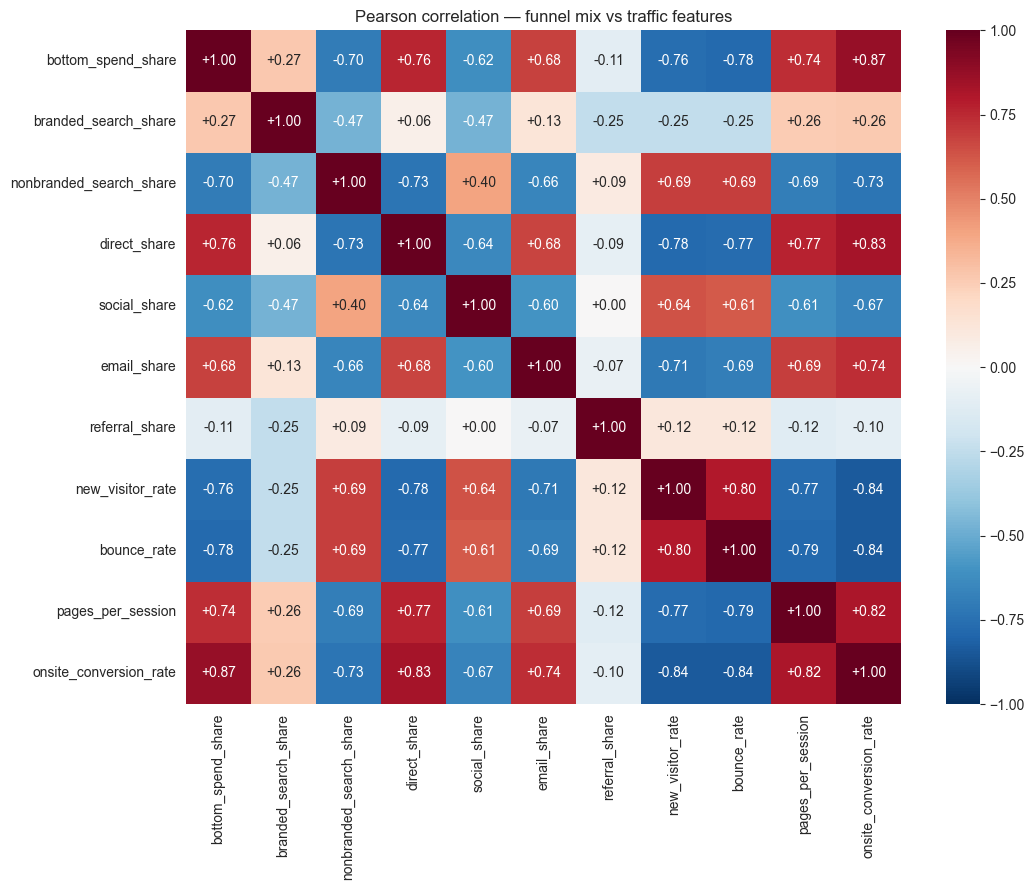

Correlation of every traffic feature with bottom_spend_share:
bounce_rate               -0.775867
new_visitor_rate          -0.760859
nonbranded_search_share   -0.696525
social_share              -0.618520
referral_share            -0.105069
branded_search_share       0.272782
email_share                0.684037
pages_per_session          0.741408
direct_share               0.763674
onsite_conversion_rate     0.872270
Name: bottom_spend_share, dtype: float64


In [8]:
corr_cols = ["bottom_spend_share"] + share_cols + quality_cols
corr = df[corr_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation — funnel mix vs traffic features")
plt.tight_layout(); plt.show()

print("Correlation of every traffic feature with bottom_spend_share:")
print(corr["bottom_spend_share"].drop("bottom_spend_share").sort_values())


## 6. Customer segmentation view

Average each customer's funnel mix over the year, bucket into three strategy
groups, and compare their *typical* traffic profile. This is the clearest way to
communicate the finding to a non-technical stakeholder.


In [9]:
cust = df.groupby("customer_id").agg(
    avg_bottom_share=("bottom_spend_share", "mean"),
    **{c: (c, "mean") for c in share_cols + quality_cols}
).reset_index()

cust["strategy"] = pd.cut(cust.avg_bottom_share,
                          bins=[-0.01, 0.34, 0.66, 1.01],
                          labels=["top-heavy", "balanced", "bottom-heavy"])
print(cust.strategy.value_counts())
print()
profile = cust.groupby("strategy")[share_cols + quality_cols].mean().round(3)
print(profile.T)


top-heavy       50
balanced        44
bottom-heavy    26
Name: strategy, dtype: int64

strategy                 top-heavy  balanced  bottom-heavy
branded_search_share         0.275     0.290         0.308
nonbranded_search_share      0.294     0.233         0.167
direct_share                 0.124     0.195         0.264
social_share                 0.166     0.111         0.067
email_share                  0.035     0.066         0.093
referral_share               0.104     0.102         0.100
new_visitor_rate             0.826     0.718         0.633
bounce_rate                  0.642     0.559         0.458
pages_per_session            2.759     3.296         3.863
onsite_conversion_rate       0.015     0.026         0.038


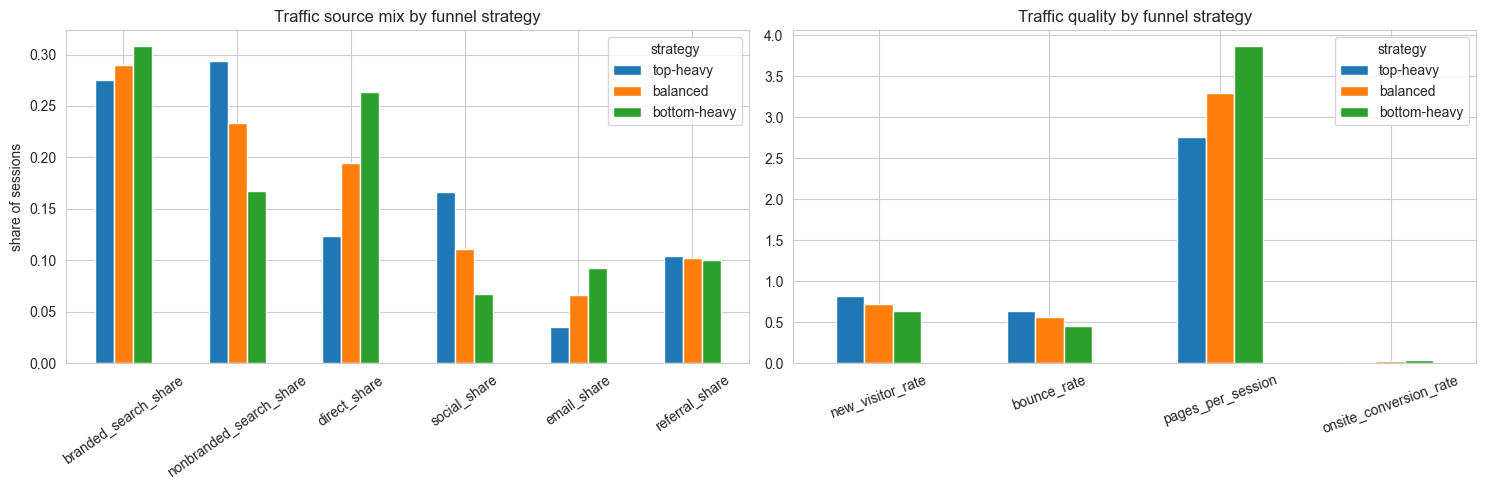

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
profile[share_cols].T.plot(kind="bar", ax=axes[0])
axes[0].set_title("Traffic source mix by funnel strategy")
axes[0].set_ylabel("share of sessions")
axes[0].tick_params(axis="x", rotation=35)
profile[quality_cols].T.plot(kind="bar", ax=axes[1])
axes[1].set_title("Traffic quality by funnel strategy")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


## Conclusions

- **Funnel mix is measured as bottom-funnel spend share** — normalised, in [0, 1],
  reflects where money actually goes.
- **No-campaign months were dropped** (count reported above) because funnel mix is
  genuinely undefined there.
- The correlation heatmap + segmentation bars answer the core question: read the
  sign and size of `bottom_spend_share`'s correlations to state whether funnel
  strategy leaves a fingerprint in (a) traffic source composition and (b) traffic
  quality.
- **Caveat:** these are correlations, not causation, and the campaign labels are
  themselves model predictions — so error from Part 1 propagates here. Customers
  with low Part-1 confidence could be excluded as a robustness check.
